In [ ]:
# Proyecto: Gestión segura de datos de clientes mediante técnicas de anonimización y pseudonimización

# Librerías necesarias
import pandas as pd 
import numpy as np 
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

# Creación del DataFrame
ruta = "C:/Users/noeli/Desktop/Big Data IA/Etica y Privacidad Data Science/Proyecto Gestión Segura Datos Clientes/clientes.csv"
df = pd.read_csv(ruta)
print(f"Datos originales:\n{df.head(10)}") # Observamos que el dataframe contiene datos sensibles de clientes (nombre completo, dirección, edad y salario)

# 1. Anonimización en los campos dirección, edad y salario:
df["edad"] = (df["edad"] // 10) * 10 # redondeamos la edad de los clientes a la decena (eliminamos el resto) para no exponer la edad real de las personas.

df["direccion"] = np.random.permutation(df["direccion"]) # Con la permutación (shuffling) cambiamos el orden de las direcciones para perder la relación entre estas y los clientes a las
# que pertenecen.

ruido = np.random.normal(0, 100, size=df["salario"].shape) # añadimos ruido aleatorio al salario para desvincularlo de los valores reales pero preservando su valor estadístico.
# El primer parámetro, el ruido promedio, será cero para no sesgar la media original; el segundo parámetro, la desviación estándar, controla que tan grandes o pequeños pueden ser 
# los cambios en los valores; y el parámetro size indica que el tamaño del array numpy de nº aleatorios será el del número de filas de la columna "salario".  
df["salario"] = df["salario"] + ruido # sumamos el ruido al df original.

# 2. Pseudonimización en el campo nombre a través de la técnica del hashing: convertimos cada nombre en una cadena de caracteres fija y determinista, ya que a diferencia de los UUIDs,
# que generan códigos alfanuméricos aleatorios, el hashing distorsiona los datos a partir del original.
def hash_data(data):
    return hashlib.sha256(data.encode()).hexdigest()

hash_nombres = []

for n in df["nombre"]:
    h_nombre = hash_data(n)
    hash_nombres.append(h_nombre)

df["nombre"] = hash_nombres

# 3. Corregimos el sesgo de desbalance de datos:
agrupado = df.groupby("categoria") # primero agrupamos el DataFrame por la columna "categoria"

df_balanceado = pd.DataFrame() # creamos un dataframe vacío donde posteriormente añadiremos los datos originales y los balanceados.

for nombre, grupo in agrupado:
    grupo_balanceado = resample(grupo, replace=True, n_samples=100, random_state=42) # creamos un grupo balanceado a partir del original, con 100 valores por categoría, siempre
    # aleatorizados a partir de la misma semilla. Con replace=True permitimos duplicar filas si así sucede en la aleatorización.
    df_balanceado = pd.concat([df_balanceado, grupo_balanceado])

# 4. Visualizamos los nuevos datos balanceados y anonimizados:
print(f"Nuevos datos:\n{df_balanceado.head(10)}") # Podemos observar como ahora los nombres son códigos alfanuméricos, las direcciones están mezcladas, la edad redondeada a la década y las categorías balanceadas
# al tener la misma representación. Los salarios, gracias al ruido gausiano, también están anonimizados.

Datos originales:
               nombre      direccion  edad  categoria  salario
0      Richard Martin    784 Stevens    62          0    61050
1         James Jones     729 Neruda    65          1    53824
2     Patricia Wilson  935 Dickinson    18          0    60281
3  Elizabeth Robinson      459 Rilke    21          1    42187
4       Charles Brown   823 Ginsberg    21          1    37589
5     Michael Jackson      854 Frost    57          1    58179
6         Mary Miller      699 Plath    27          1    40359
7        Linda Harris      572 Auden    37          0    41725
8         Sarah Davis    496 Whitman    39          0    44533
9         Susan Moore    586 Mistral    68          0    50209
Nuevos datos:
                                                nombre    direccion  edad  \
122  13713265a569562bcc8fe3af404eef236db0495eab5dcf...   523 Goethe    30   
35   0670d2dfd7b13c48d6f05684b81351fdf5926862f5b626...  374 Whitman    10   
173  ddcc79df972adedbc5a0fe85bf608d0efdc1aa9

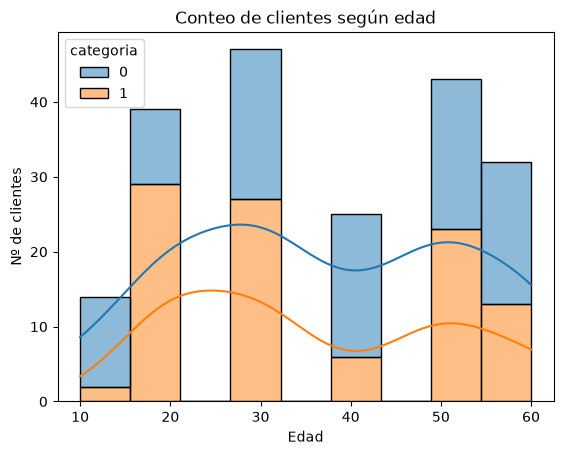

In [ ]:
# 5. Distribución de salarios según categorías (histplot)
histograma = sns.histplot(
    data= df_balanceado,
    x="edad",
    kde=True,
    hue="categoria",
    multiple="stack"
)
histograma.set_xlabel("Edad")
histograma.set_ylabel("Nº de clientes")
histograma.set_title("Conteo de clientes según edad") 

plt.show() # Observamos que los tramos de edad a la que pertenecen más clientes son los 30 y los 50 años, y que la categoría más abundante es la 0.

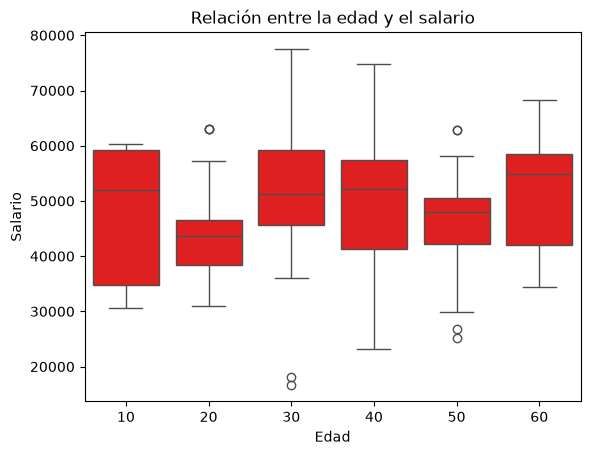

In [ ]:
# 6. Relación entre edad y salario (boxplot)
boxplot = sns.boxplot(
    data=df_balanceado,
    x="edad",
    y="salario",
    color="red"
)

boxplot.set_xlabel("Edad")
boxplot.set_ylabel("Salario")
boxplot.set_title("Relación entre la edad y el salario") 

plt.show() # Podemos observar que no hay una relación clara entre la edad y salario, debido a que los datos del csv son ficticios. Se observa igualmente el efecto de la aplicación de 
# técnicas de anonimización, puesto que la edad se agrupa por décadas y el salario sigue conservando sus propiedades estadísticas globales.